# The multilayer perceptron — Solutions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from variable import Variable, exp

## XOR data

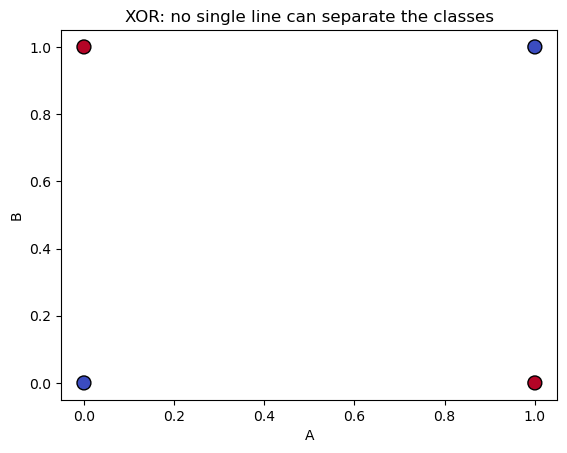

In [2]:
def xor():
    A_B = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    XOR = np.array([0, 1, 1, 0])
    return A_B, XOR


A_B, XOR = xor()
plt.scatter(A_B[:, 0], A_B[:, 1], c=XOR, cmap="coolwarm", s=100, edgecolors="k")
plt.xlabel("A")
plt.ylabel("B")
plt.title("XOR: no single line can separate the classes")
plt.show()

## Exercise 1: Single perceptron

In [3]:
class Perceptron2D:
    def __init__(self, T=0, lr=1e-1):
        self.T = T
        self.lr = lr
        self.w1 = Variable(np.random.uniform())
        self.w2 = Variable(np.random.uniform())
        self.bias = Variable(-1)

    def forward(self, A, B):
        y_hat = A * self.w1 + B * self.w2 + self.bias
        return y_hat

    def evaluate(self, A, B):
        y_hat = self.forward(A, B)
        return y_hat.value > self.T

    def loss_fn(self, A, B, y):
        y_hat = self.forward(A, B)
        return (y_hat - y) ** 2

    def gradient_step(self, A, B, y):
        loss = self.loss_fn(A, B, y)
        grads = loss.gradients
        # Update weights (not the bias)
        w1 = self.w1 - self.lr * grads[self.w1]
        w2 = self.w2 - self.lr * grads[self.w2]
        # Re-wrap as Variable to avoid infinite recursion in the graph
        self.w1 = Variable(w1.value)
        self.w2 = Variable(w2.value)
        return loss.value

## Exercise 2: Training loop

In [4]:
def train(model, A_B, XOR, epochs=1000):
    loss_history = []
    for epoch in range(epochs):
        loss = 0
        for i in range(len(XOR)):
            A, B = A_B[i]
            y = XOR[i]
            loss += model.gradient_step(Variable(A), Variable(B), Variable(y))
        loss_history.append(loss)
    return loss_history

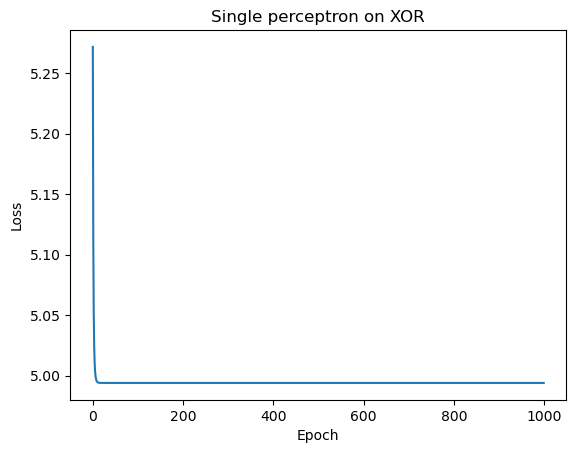

In [5]:
model = Perceptron2D()
loss_history = train(model, A_B, XOR, epochs=1000)

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Single perceptron on XOR")
plt.show()

## Decision boundary

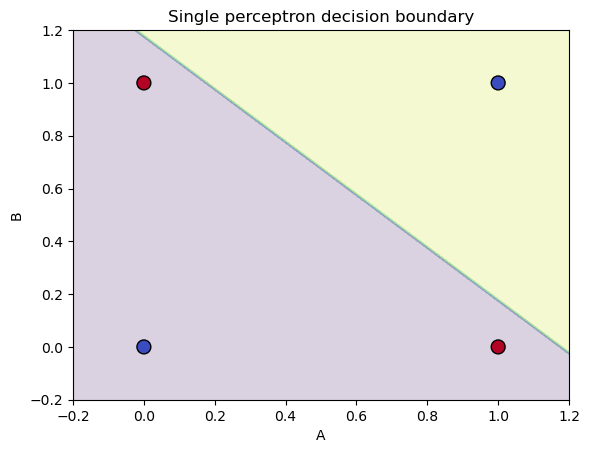

In [6]:
def plot_decision_boundary(model, A_B, XOR, fig=None, ax=None):
    x = np.linspace(-0.2, 1.2, 100)
    y = np.linspace(-0.2, 1.2, 100)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    for i in range(len(X)):
        for j in range(len(X[0])):
            Z[i, j] = model.evaluate(Variable(X[i, j]), Variable(Y[i, j]))
    if fig is None or ax is None:
        fig, ax = plt.subplots()
    ax.contourf(X, Y, Z, alpha=0.2)
    ax.scatter(A_B[:, 0], A_B[:, 1], c=XOR, cmap="coolwarm", s=100, edgecolors="k")
    ax.set_xlabel("A")
    ax.set_ylabel("B")
    return fig, ax


plot_decision_boundary(model, A_B, XOR)
plt.title("Single perceptron decision boundary")
plt.show()

## Exercise 3a: Stacking linear layers

**Two layers.** Starting with $f_1(x) = W_1 x + b_1$ and $f_2(z) = W_2 z + b_2$:

$$ f_2(f_1(x)) = W_2(W_1 x + b_1) + b_2 = \underbrace{W_2 W_1}{W'} x + \underbrace{W_2 b_1 + b_2}{b'} $$

This is just a single linear transformation $W'x + b'$.

**Three layers.** Adding $f_3(z) = W_3 z + b_3$:

$$ f_3(f_2(f_1(x))) = W_3(W_2 W_1 x + W_2 b_1 + b_2) + b_3 = \underbrace{W_3 W_2 W_1}{W'} x + \underbrace{W_3 W_2 b_1 + W_3 b_2 + b_3}{b'} $$

Still a single linear transformation.

**General case.** By induction, for $n$ layers:

$$ f(x) = \underbrace{W_n W_{n-1} \cdots W_1}{W'} x + \underbrace{W_n W{n-1} \cdots W_2 b_1 + \cdots + W_n b_{n-1} + b_n}_{b'} $$

**Conclusion:** No matter how many linear layers we stack, the result is always equivalent to a single linear layer. Depth alone does not increase the expressiveness of a linear model. This is why we need nonlinear activation functions between layers.

## Exercise 3b: Polynomial activations

**Part 1.** With $f_1(x) = W_1 x^2$ and $f_2(z) = W_2 z^2$:

$$ f_2(f_1(x)) = W_2 (W_1 x^2)^2 = W_2 W_1^2 , x^4 $$

The result is a degree-4 polynomial.

**Part 2.** A single-layer network $g(x) = W' x^4$ can represent the same function by setting $W' = W_2 W_1^2$. So the two-layer polynomial network is no more expressive than a single-layer one with a higher-degree polynomial.

More generally, stacking $n$ layers of degree-$k$ polynomials gives a degree-$k^n$ polynomial — but a single layer with degree $k^n$ can represent the same family of functions. The composition only increases the degree, not the class of representable functions. This is fundamentally different from what happens with non-polynomial nonlinearities like sigmoid or ReLU, which create function classes that genuinely cannot be collapsed.

## Sigmoid and XOR decomposition

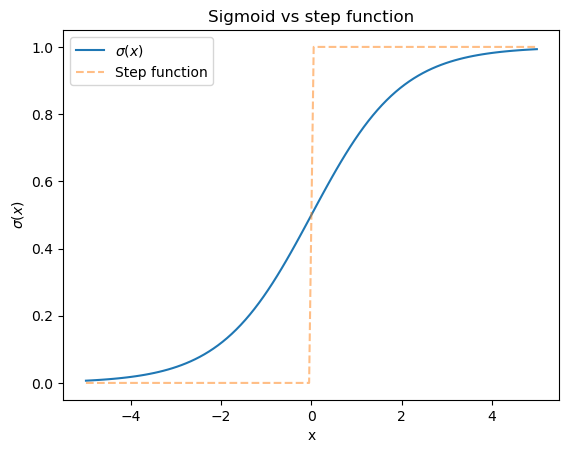

In [7]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


x = np.linspace(-5, 5, 100)
plt.plot(x, sigmoid(x), label=r"$\sigma(x)$")
plt.plot(x, (x > 0).astype(float), "--", label="Step function", alpha=0.5)
plt.xlabel("x")
plt.ylabel(r"$\sigma(x)$")
plt.legend()
plt.title("Sigmoid vs step function")
plt.show()

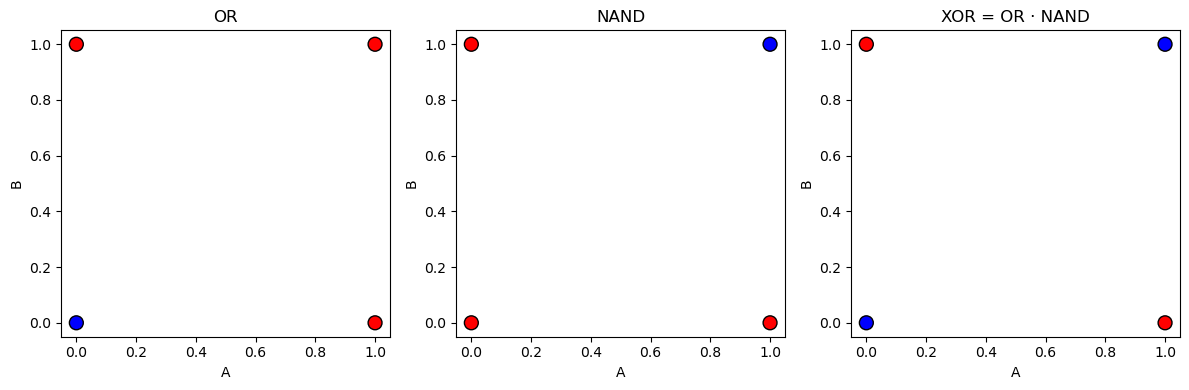

In [8]:
A, B = A_B.T
fig, ax = plt.subplots(ncols=3, figsize=(12, 4))
ax[0].scatter(A, B, c=A | B, cmap="bwr", s=100, edgecolors="k")
ax[0].set_title("OR")
ax[1].scatter(A, B, c=~(A & B), cmap="bwr", s=100, edgecolors="k")
ax[1].set_title("NAND")
ax[2].scatter(A, B, c=A ^ B, cmap="bwr", s=100, edgecolors="k")
ax[2].set_title("XOR = OR · NAND")
for a in ax:
    a.set_xlabel("A")
    a.set_ylabel("B")
plt.tight_layout()
plt.show()

## Exercise 4: Two-layer MLP

In [9]:
class MLP:
    def __init__(self, T=0.5, lr=1e-1):
        self.T, self.lr = T, lr
        # Hidden layer: neuron 1
        self.w11 = Variable(np.random.normal(scale=0.1))
        self.w12 = Variable(np.random.normal(scale=0.1))
        self.b11 = Variable(np.random.normal(scale=0.01))
        # Hidden layer: neuron 2
        self.w13 = Variable(np.random.normal(scale=0.1))
        self.w14 = Variable(np.random.normal(scale=0.1))
        self.b12 = Variable(np.random.normal(scale=0.01))
        # Output layer
        self.w21 = Variable(np.random.normal(scale=0.1))
        self.w22 = Variable(np.random.normal(scale=0.1))
        self.b21 = Variable(np.random.normal(scale=0.01))

    def _sigmoid(self, x):
        return 1 / (1 + exp(-x))

    def forward(self, A, B):
        # Hidden layer
        z1 = A * self.w11 + B * self.w12 + self.b11
        z2 = A * self.w13 + B * self.w14 + self.b12
        h1 = self._sigmoid(z1)
        h2 = self._sigmoid(z2)
        # Output layer
        z_out = h1 * self.w21 + h2 * self.w22 + self.b21
        return self._sigmoid(z_out)

    def evaluate(self, A, B):
        y_hat = self.forward(A, B)
        return y_hat.value > self.T

    def loss_fn(self, A, B, y):
        y_hat = self.forward(A, B)
        return (y_hat - y) ** 2

    def gradient_step(self, A, B, y):
        loss = self.loss_fn(A, B, y)
        grads = loss.gradients
        self.w11 = Variable((self.w11 - self.lr * grads[self.w11]).value)
        self.w12 = Variable((self.w12 - self.lr * grads[self.w12]).value)
        self.w13 = Variable((self.w13 - self.lr * grads[self.w13]).value)
        self.w14 = Variable((self.w14 - self.lr * grads[self.w14]).value)
        self.b11 = Variable((self.b11 - self.lr * grads[self.b11]).value)
        self.b12 = Variable((self.b12 - self.lr * grads[self.b12]).value)
        self.w21 = Variable((self.w21 - self.lr * grads[self.w21]).value)
        self.w22 = Variable((self.w22 - self.lr * grads[self.w22]).value)
        self.b21 = Variable((self.b21 - self.lr * grads[self.b21]).value)
        return loss.value

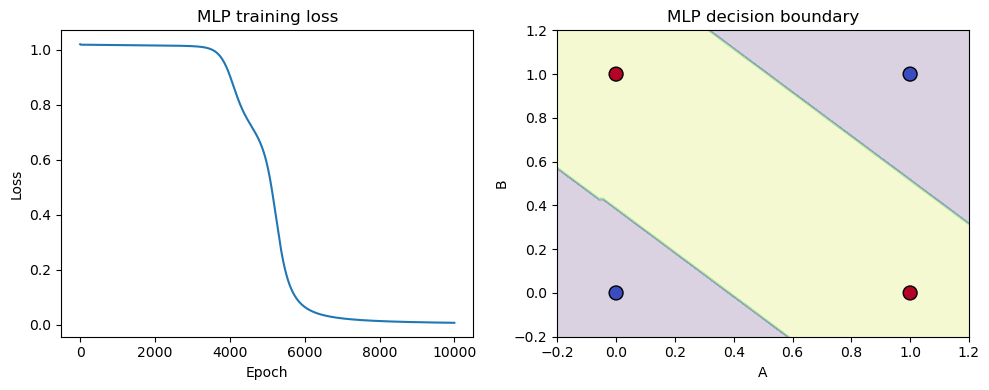

In [10]:
model = MLP(lr=1e-1)
loss_history = train(model, A_B, XOR, epochs=10000)

fig, axs = plt.subplots(ncols=2, figsize=(10, 4))
axs[0].plot(loss_history)
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].set_title("MLP training loss")

plot_decision_boundary(model, A_B, XOR, fig=fig, ax=axs[1])
axs[1].set_title("MLP decision boundary")
plt.tight_layout()
plt.show()